All the X-ray analysis in one place. Light curves and Lx plot. Fitting the spectra. Is the G203 upper limit worth an XMM observation?

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import astropy.io.fits as fits
import os
import glob
from astropy.table import Table
from astropy.io import ascii
from astropy.convolution import convolve, Box1DKernel, Gaussian1DKernel
import astropy.constants as const
import astropy.units as u
import importlib
from astropy.modeling import models, fitting
from astropy.time import Time


#matplotlib set up
%matplotlib inline
from matplotlib import rcParams
rcParams["figure.figsize"] = (14, 5)
rcParams["font.size"] = 20

In [3]:
swiftlc = Table.read('/media/david/2tb_ext_hd/hddata/carmenes_binary/gj207.1/swift/xrt/USERPROD_247053/lc/curve.qdp')
# swiftlc
xtime = swiftlc['col1']
xcounts = swiftlc['col2']
xcounts_e = np.array([swiftlc['col2_perr'], abs(swiftlc['col2_nerr'])])

<ErrorbarContainer object of 3 artists>

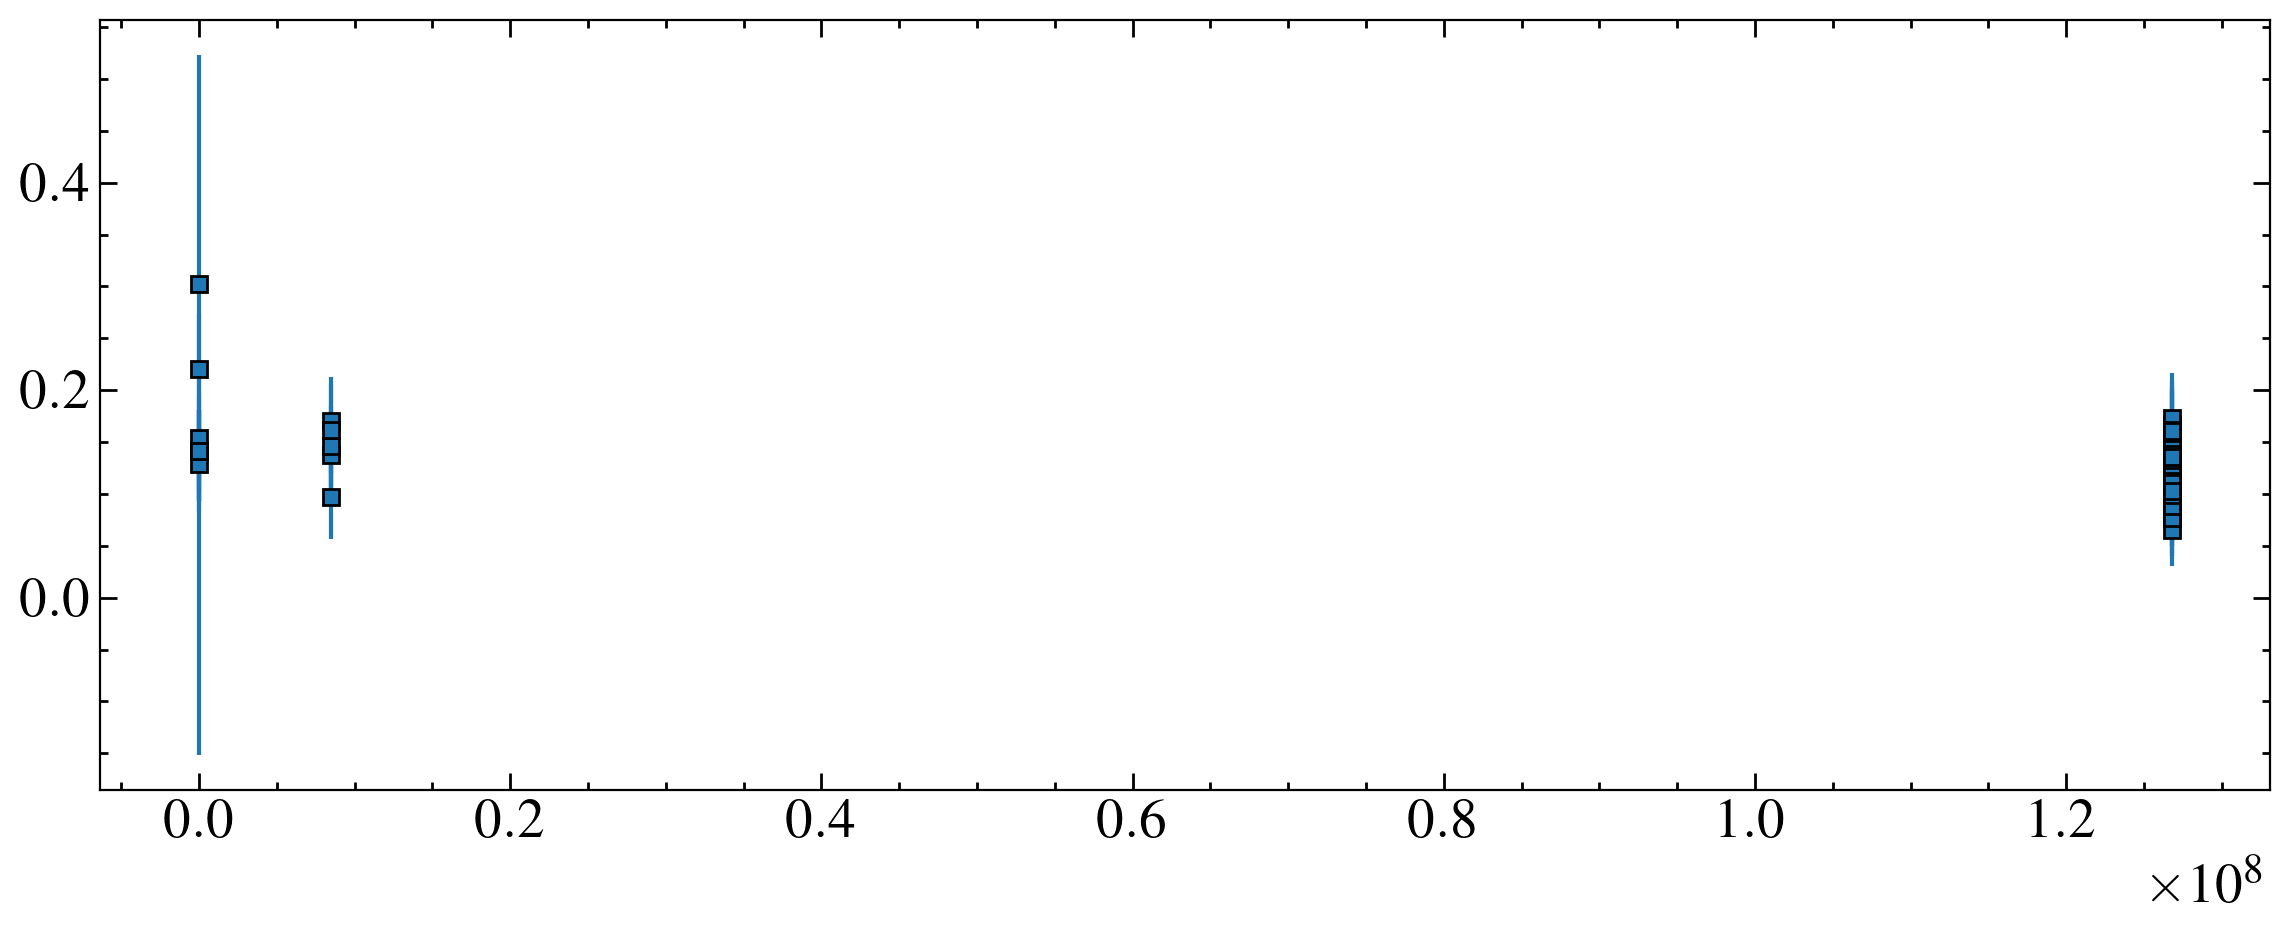

In [4]:
fig, ax = plt.subplots()

ax.errorbar(xtime, xcounts, yerr = xcounts_e, marker='s', ls='none', markeredgecolor='k', label=r'XRT')


In [5]:
swiftlc = Table.read('/media/david/2tb_ext_hd/hddata/carmenes_binary/wolf1130/swift/xrt/lc/USERPROD_251678/lc/curve.qdp')
# swiftlc
xtime = swiftlc['col1']
xcounts = swiftlc['col2']
xcounts_e = np.array([swiftlc['col2_perr'], abs(swiftlc['col2_nerr'])])

<ErrorbarContainer object of 3 artists>

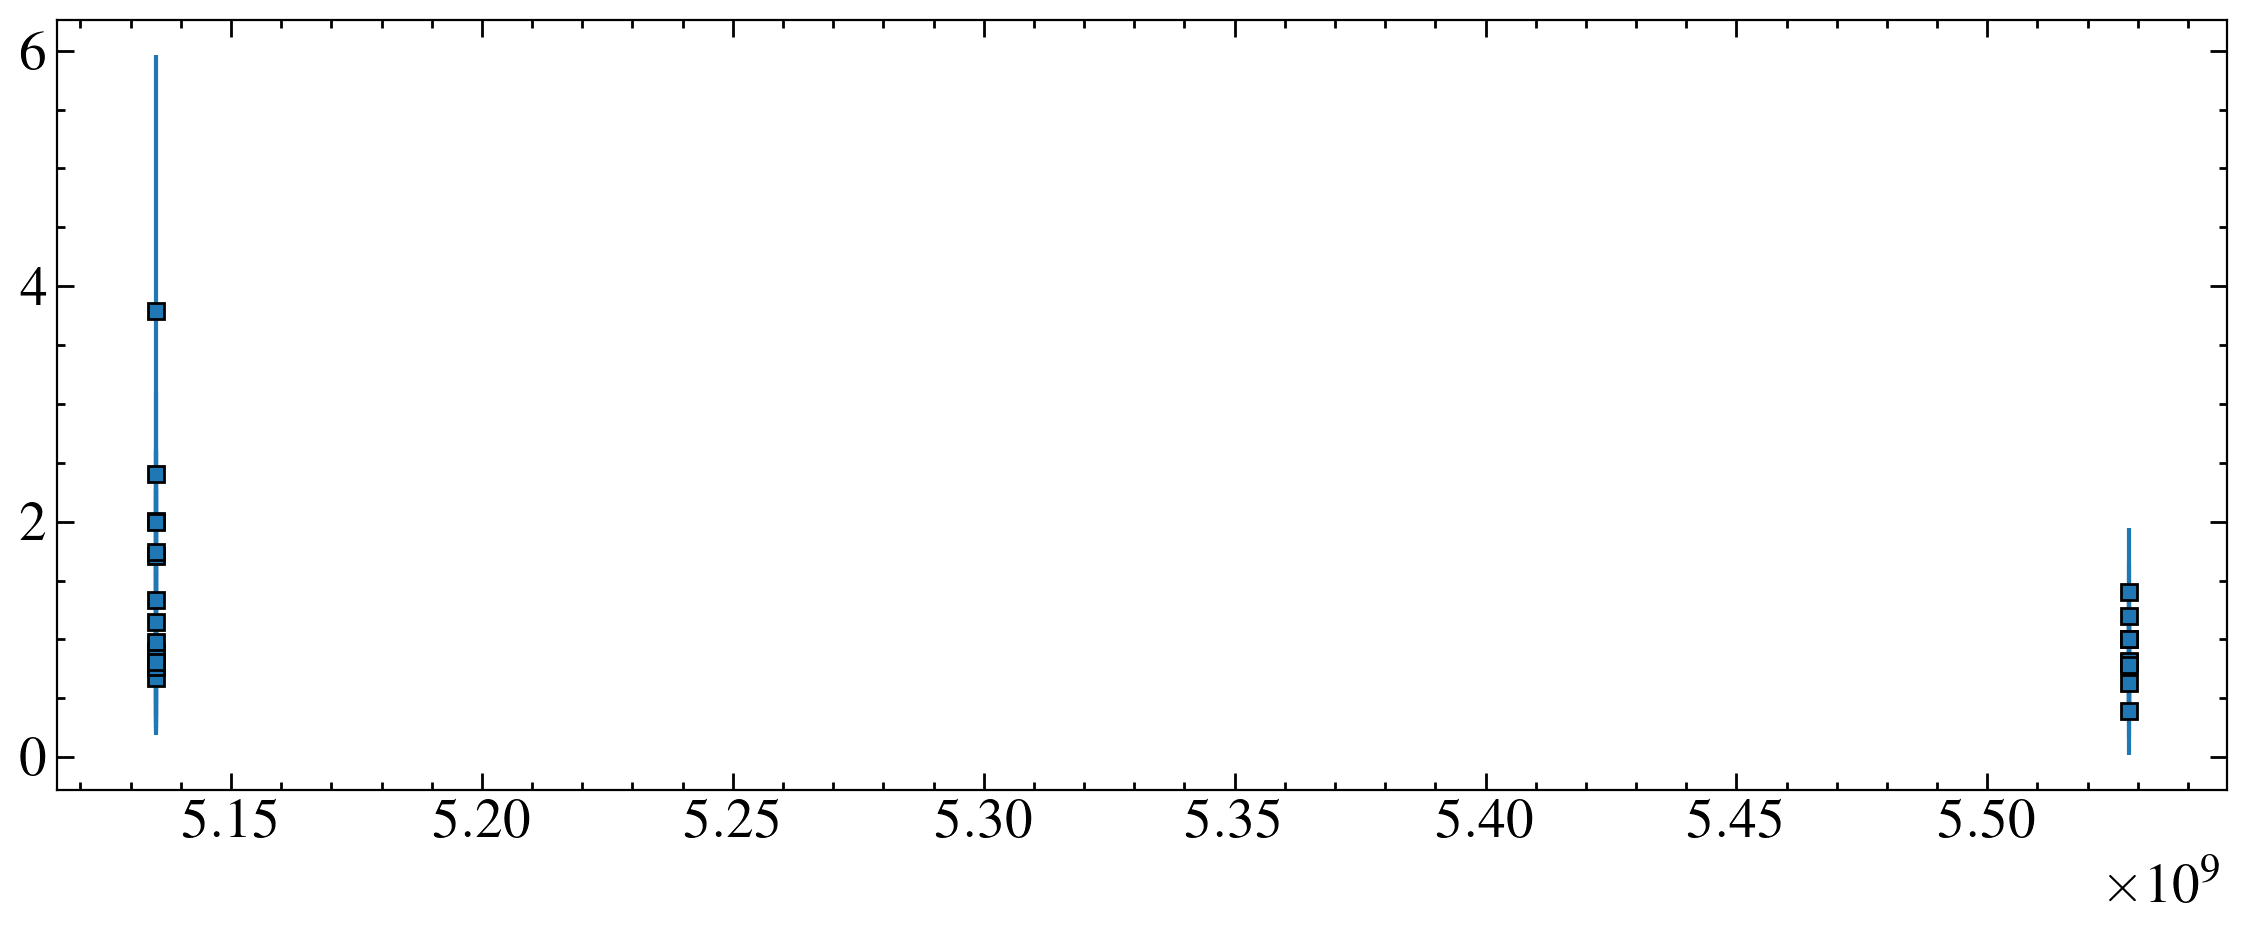

In [6]:
#swift reference times
ref_mjd = 51910
ref_sec = ref_mjd * 86400
xref = 650034242.0006 #different for X-ray

fig, ax = plt.subplots()
xmask = xtime > 0 #just this observation
xt = xtime[xmask] + xref + ref_sec
xf, xe = xcounts[xmask] / np.median(xcounts[xmask]), np.array([xcounts_e[0][xmask] / np.median(xcounts[xmask]), xcounts_e[1][xmask] / np.median(xcounts[xmask])])
ax.errorbar(xt, xf, yerr = xe, marker='s', ls='none', markeredgecolor='k', label=r'XRT')


In [7]:
swiftlc = Table.read('/media/david/2tb_ext_hd/hddata/carmenes_binary/lhs1817/swift/xrt/lightcurve/USERPROD_255053/lc/curve.qdp')
# swiftlc
xtime = swiftlc['col1']
xcounts = swiftlc['col2']
xcounts_e = np.array([swiftlc['col2_perr'], abs(swiftlc['col2_nerr'])])

1.1189903475589191
0.7054890045356708


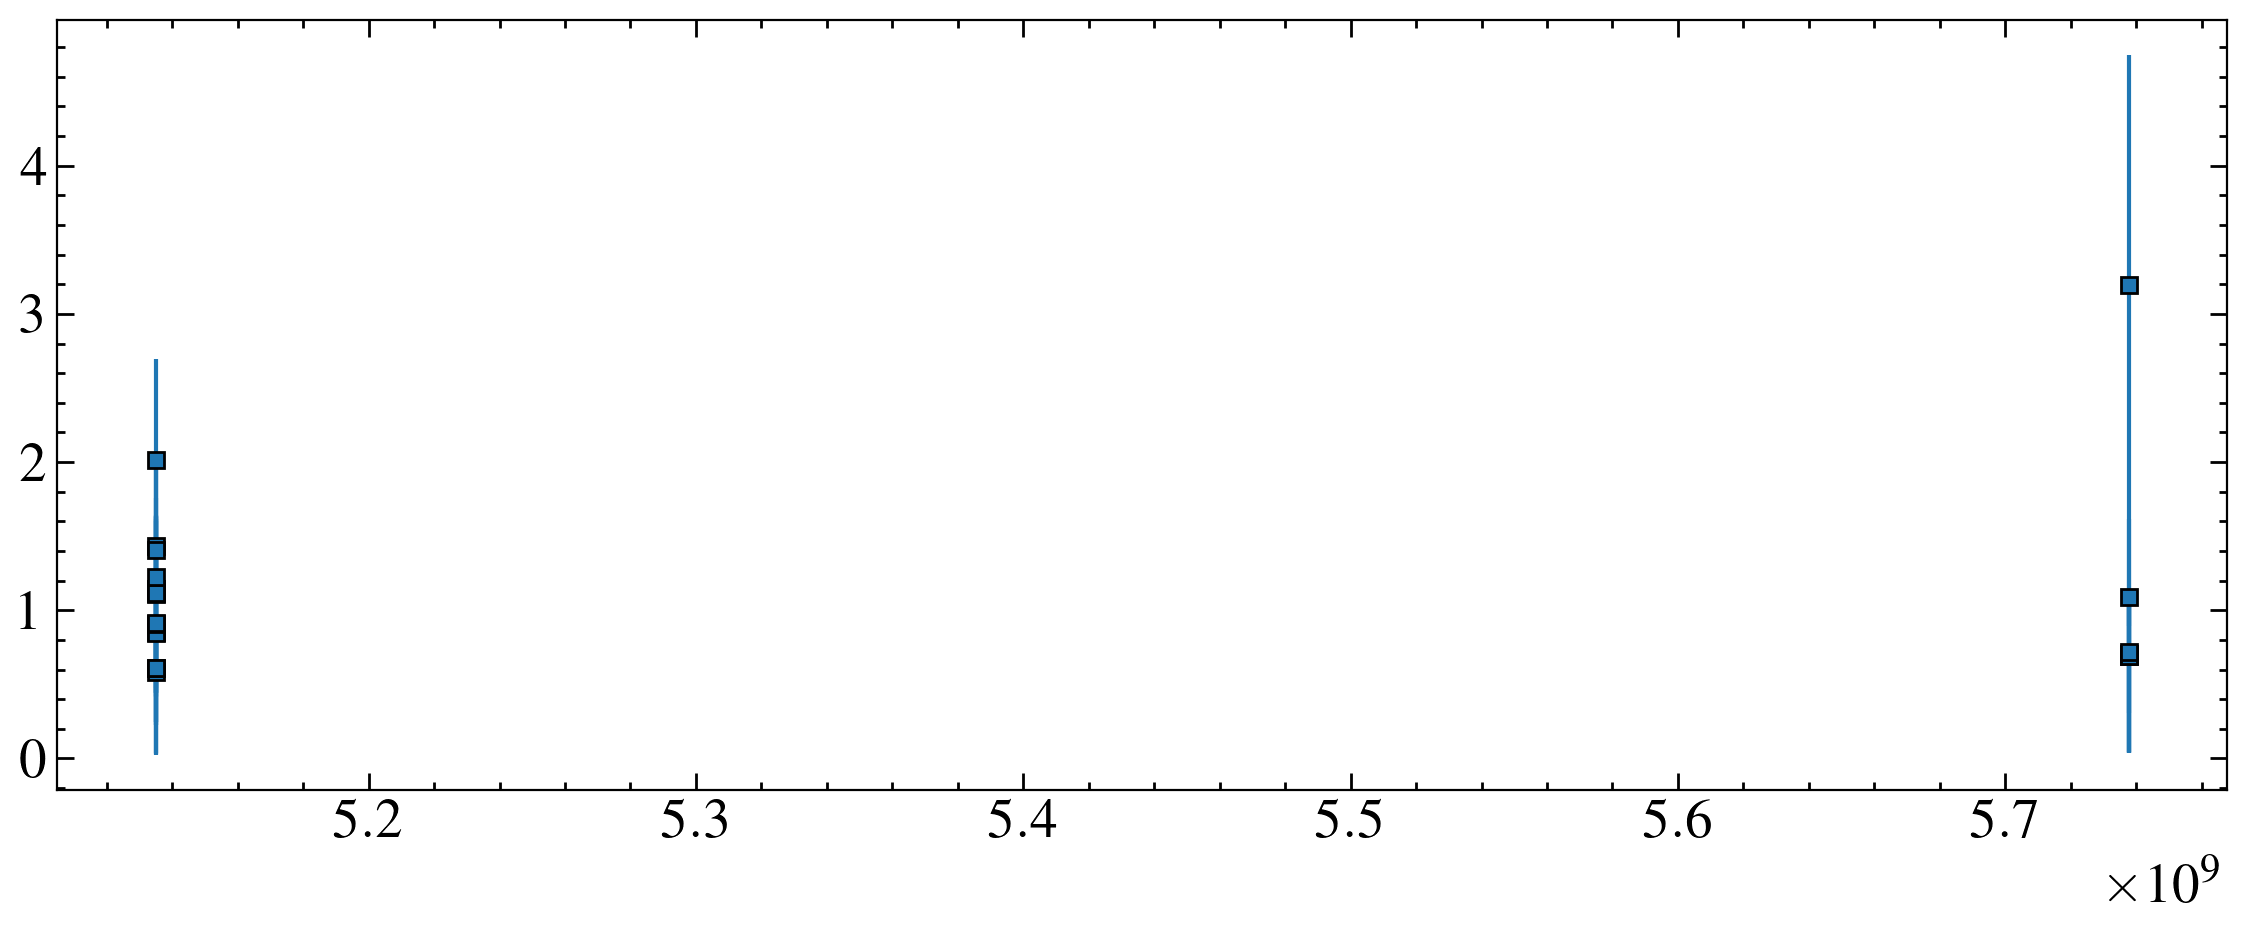

In [8]:
#swift reference times
ref_mjd = 51910
ref_sec = ref_mjd * 86400
xref = 650034242.0006 #different for X-ray

fig, ax = plt.subplots()
xmask = xtime > 0 #just this observation
xt = xtime[xmask] + xref + ref_sec
xf, xe = xcounts[xmask] / np.median(xcounts[xmask]), np.array([xcounts_e[0][xmask] / np.median(xcounts[xmask]), xcounts_e[1][xmask] / np.median(xcounts[xmask])])
ax.errorbar(xt, xf, yerr = xe, marker='s', ls='none', markeredgecolor='k', label=r'XRT')


print(np.median(xf[xt < 5.3e9]))
print(np.median(xf[xt > 5.3e9]))

472396054.7055998 1075052654.7055998


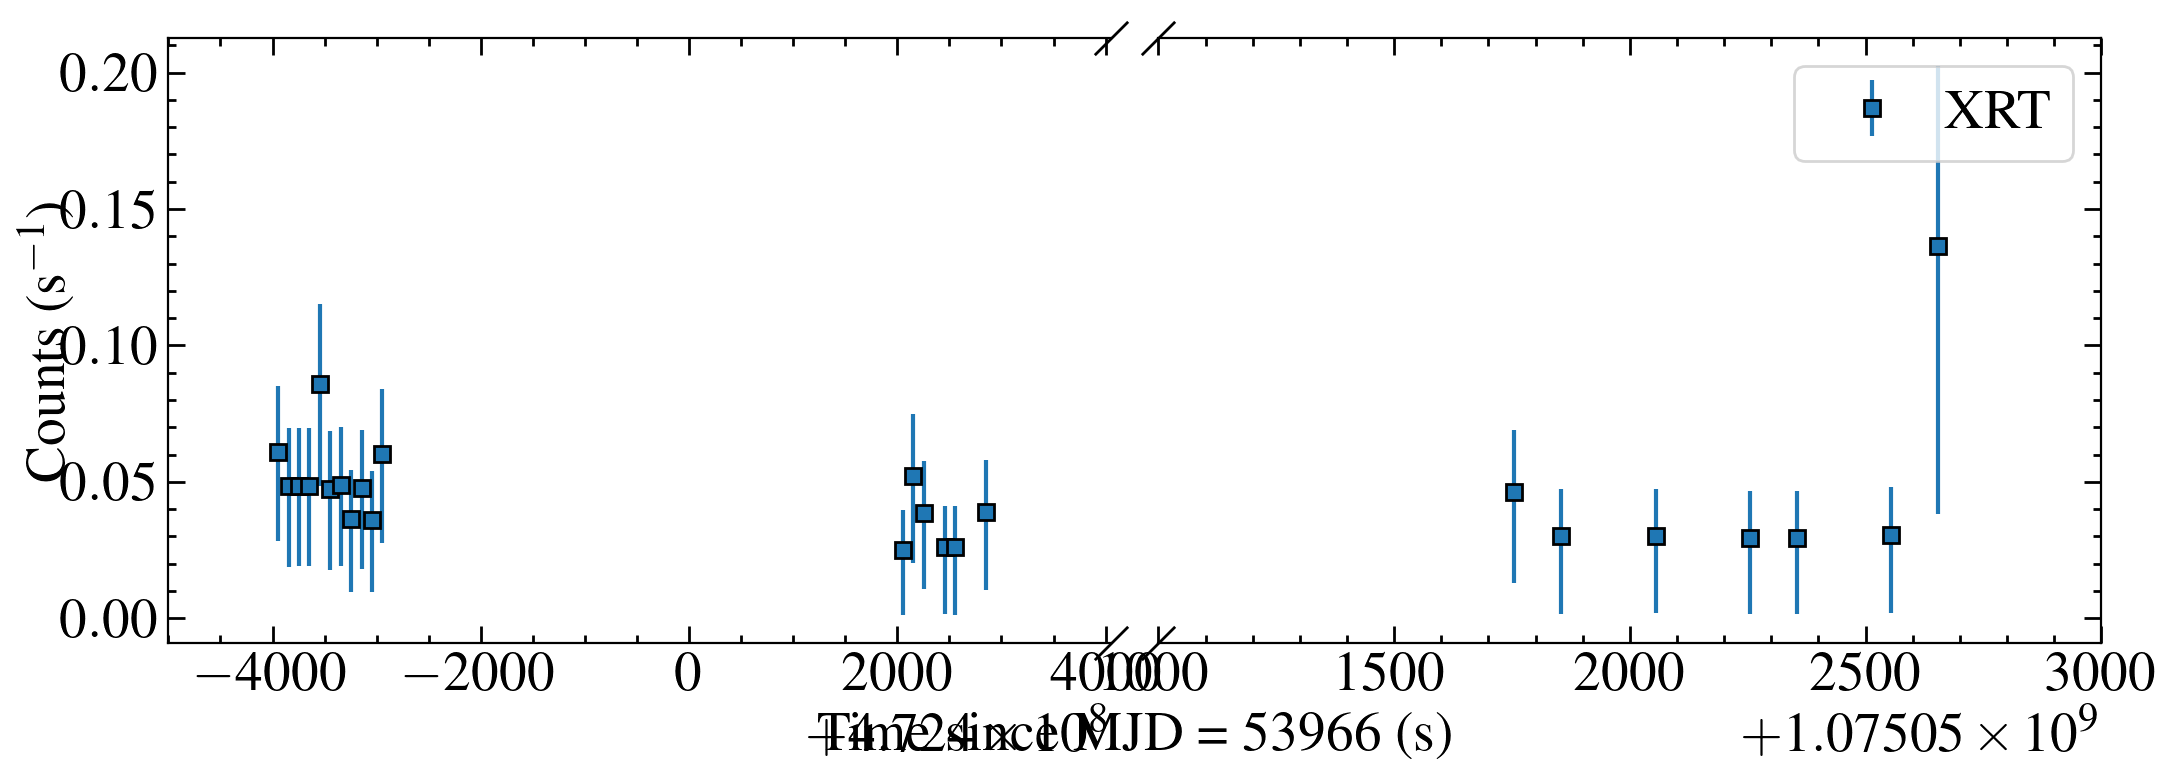

In [9]:
fig, axes = plt.subplots(ncols=2, sharey = True, figsize=(12, 5)) 

#swift reference times
ref_mjd = 51910
ref_sec = ref_mjd * 86400

xref = 650034242.0006 #different for X-ray

mjd0 = 53966 #day of first XRT observation

# for i,  lc in enumerate(lcs[::-1][1]):
for j in range(len(axes)):

   
    #xrt
    # xmask = xtime > 0 #just this observation
    xt = xtime + xref + ref_sec- mjd0 *86400
    xf, xe = xcounts, np.array([xcounts_e[0], xcounts_e[1] ]) 
    axes[j].errorbar(xt, xf, yerr = xe, marker='s', ls='none', markeredgecolor='k', label=r'XRT')
    
print(xt[0], xt[-1])    

# axes[0].set_ylim(0.31, 1.99) # should only need to set the ylims on the first subplot because sharey = True
axes[0].set_xlim(472395000, 472404054) #setting up the ranges that the plots will cover. One row per subplot
axes[1].set_xlim(1075051000, 1075053000)

# axes[0].legend(frameon=True, loc=3)
axes[1].legend(frameon=True, loc=1)

"""
Everything between here and the next docstring should work regardless of how many subplots you have
"""

#setting up the slanted lines
d = 1.  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)

for i in range(len(axes)):
    
    # axes[i].scatter(xs, ys, edgecolor='k') #add the points to each plot
    
    if i > 0: #turn off yticks for everything except the first plot
        axes[i].yaxis.set_tick_params(labelleft=False)
      
    if i != len(axes)-1: #do these things for every subplot exept the last
        axes[i].spines.right.set_visible(False) #turn off right ax
        axes[i].tick_params(right = False, which='both') #turn off right ticks
        axes[i].plot([1, 1], [0, 1], transform=axes[i].transAxes, **kwargs) #add the slanted line to the right corners
   
    if i > 0: #do these things for every subplot except the first
        axes[i].spines.left.set_visible(False) #as for the last loop but for the left
        axes[i].tick_params(left = False, which='both')
        axes[i].plot([0, 0], [1, 0], transform=axes[i].transAxes, **kwargs)
        
"""
Just the axes labels beyond this.
"""    
#add a frame that goes around all the subplots to add the labels       
bigax = fig.add_subplot(111, frame_on=False)
bigax.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False, which='both')
bigax.set_ylabel('Counts (s$^{-1}$)') #change labelpad if the label is overlapping the tick labels
bigax.set_xlabel('Time since MJD = {} (s)'.format(mjd0))
# bigax.set_title('Example plot with split x axis', pad =15) 

fig.tight_layout()
fig.subplots_adjust(wspace=0.05) #change the gap in between the subplots

# fig.savefig('plots/g207d1_swift_lcs.pdf')




In [10]:
# swiftlc

Ok so for both the detections we can use the last spectrum. For Wolf 1130 use spectrum number 2. Will fit them in xspec rather than mess around with pyxspec. Nope, pyxspec Estimate nh from Allison's paper? Fix at 18

GJ 207.1  
<!-- 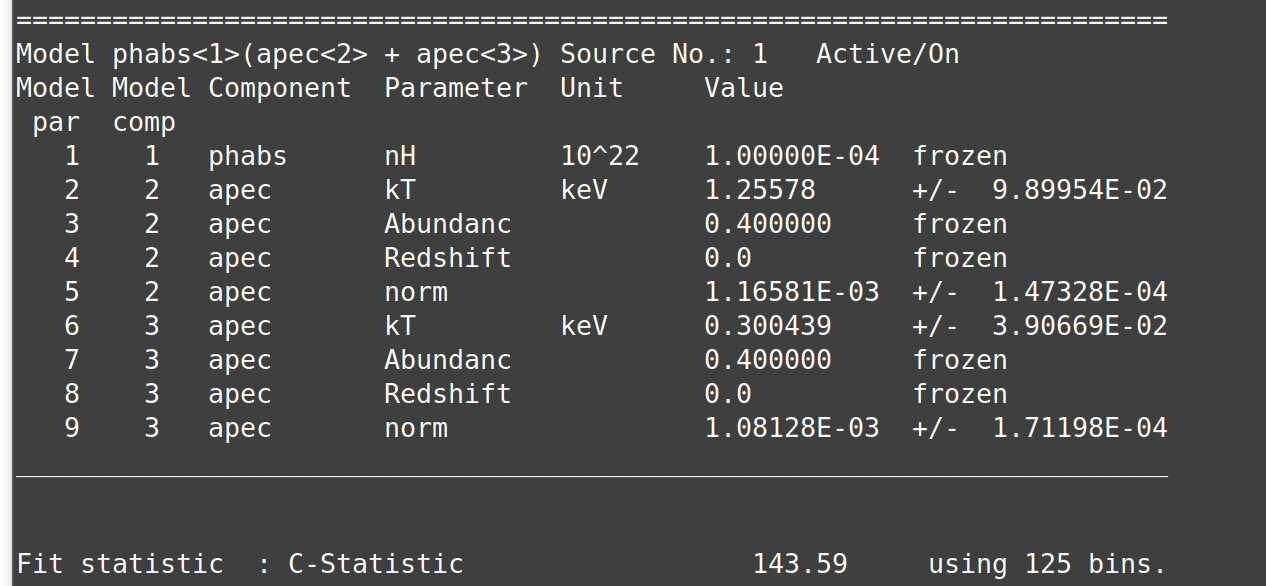 -->

In [11]:
from xspec import *
Plot.device = '/null'


In [12]:
path = '/media/david/2tb_ext_hd/hddata/carmenes_binary/'
stars = ['gj207.1', 'lhs1817', 'wolf1130']
obs = [3, 0, 2]
# for star, ob in zip(stars, obs):
    # print(os.listdir('{}{}/swift/xrt/spectra/obs{}'.format(path, star, ob)))
for i, star in enumerate(stars):
    starpath = '{}{}/swift/xrt/spectra/obs{}/'.format(path, star, obs[i])
    # print(starpath)

# obsname = ['interval0', 'Obs_00036027002', 'Obs_00040011003']
obsname = ['interval0', 'lhs1817_all', 'Obs_00040011003']

gj207.1
***Warning: Detected response matrix energy bin value = 0 (or neg).
     XSPEC will instead use small finite value (response file will not be altered).

1 spectrum  in use
 
Spectral Data File: interval0pc.pi  Spectrum 1
Net count rate (cts/s) for Spectrum:1  9.327e-02 +/- 5.710e-03 (98.7 % total)
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-254
  Telescope: SWIFT Instrument: XRT  Channel Type: PI
  Exposure Time: 2899 sec
 Using fit statistic: chi
 Using Background File                interval0pcback.pi
  Background Exposure Time: 2899 sec
 Using Response (RMF) File            interval0pc.rmf for Source 1
 Using Auxiliary Response (ARF) File  interval0pc.arf


ignore:   129 channels ignored from  source number 1

Models will now use energy array created from:
   0.1 - 2.4   1000 linear bins


Model phabs<1>(apec<2> + apec<3>) Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   phabs      nH         10^22    1.0

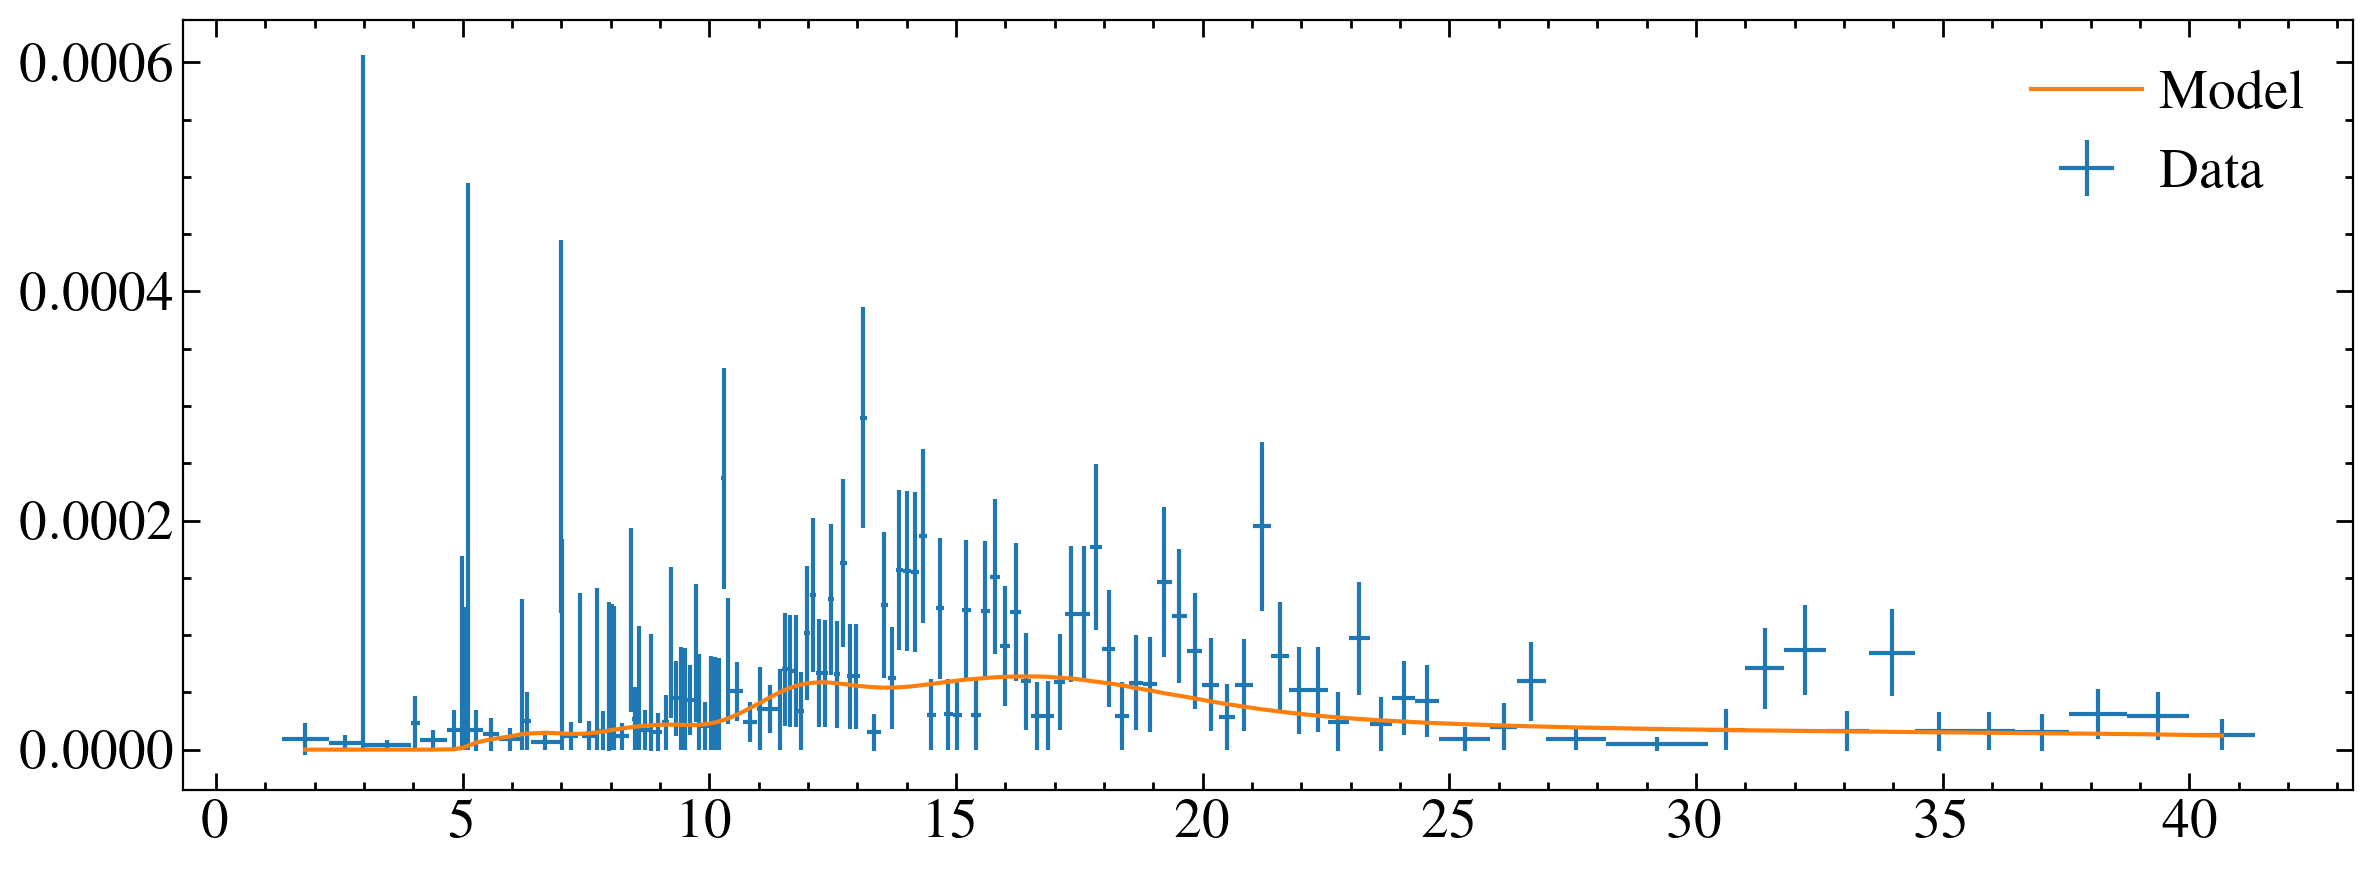

lhs1817
***Warning: Detected response matrix energy bin value = 0 (or neg).
     XSPEC will instead use small finite value (response file will not be altered).

1 spectrum  in use
 
Spectral Data File: lhs1817_allpc.pi  Spectrum 1
Net count rate (cts/s) for Spectrum:1  2.908e-02 +/- 3.063e-03 (96.4 % total)
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-672
  Telescope: SWIFT Instrument: XRT  Channel Type: PI
  Exposure Time: 3217 sec
 Using fit statistic: chi
 Using Background File                lhs1817_allpcback.pi
  Background Exposure Time: 3217 sec
 Using Response (RMF) File            lhs1817_allpc.rmf for Source 1
 Using Auxiliary Response (ARF) File  lhs1817_allpc.arf


Fit statistic  : Chi-Squared                12927.07     using 672 bins.

***Warning: Chi-square may not be valid due to bins with zero variance
            in spectrum number: 1

Test statistic : Chi-Squared                12927.07     using 672 bins.

***Warning: Chi-square may not be valid

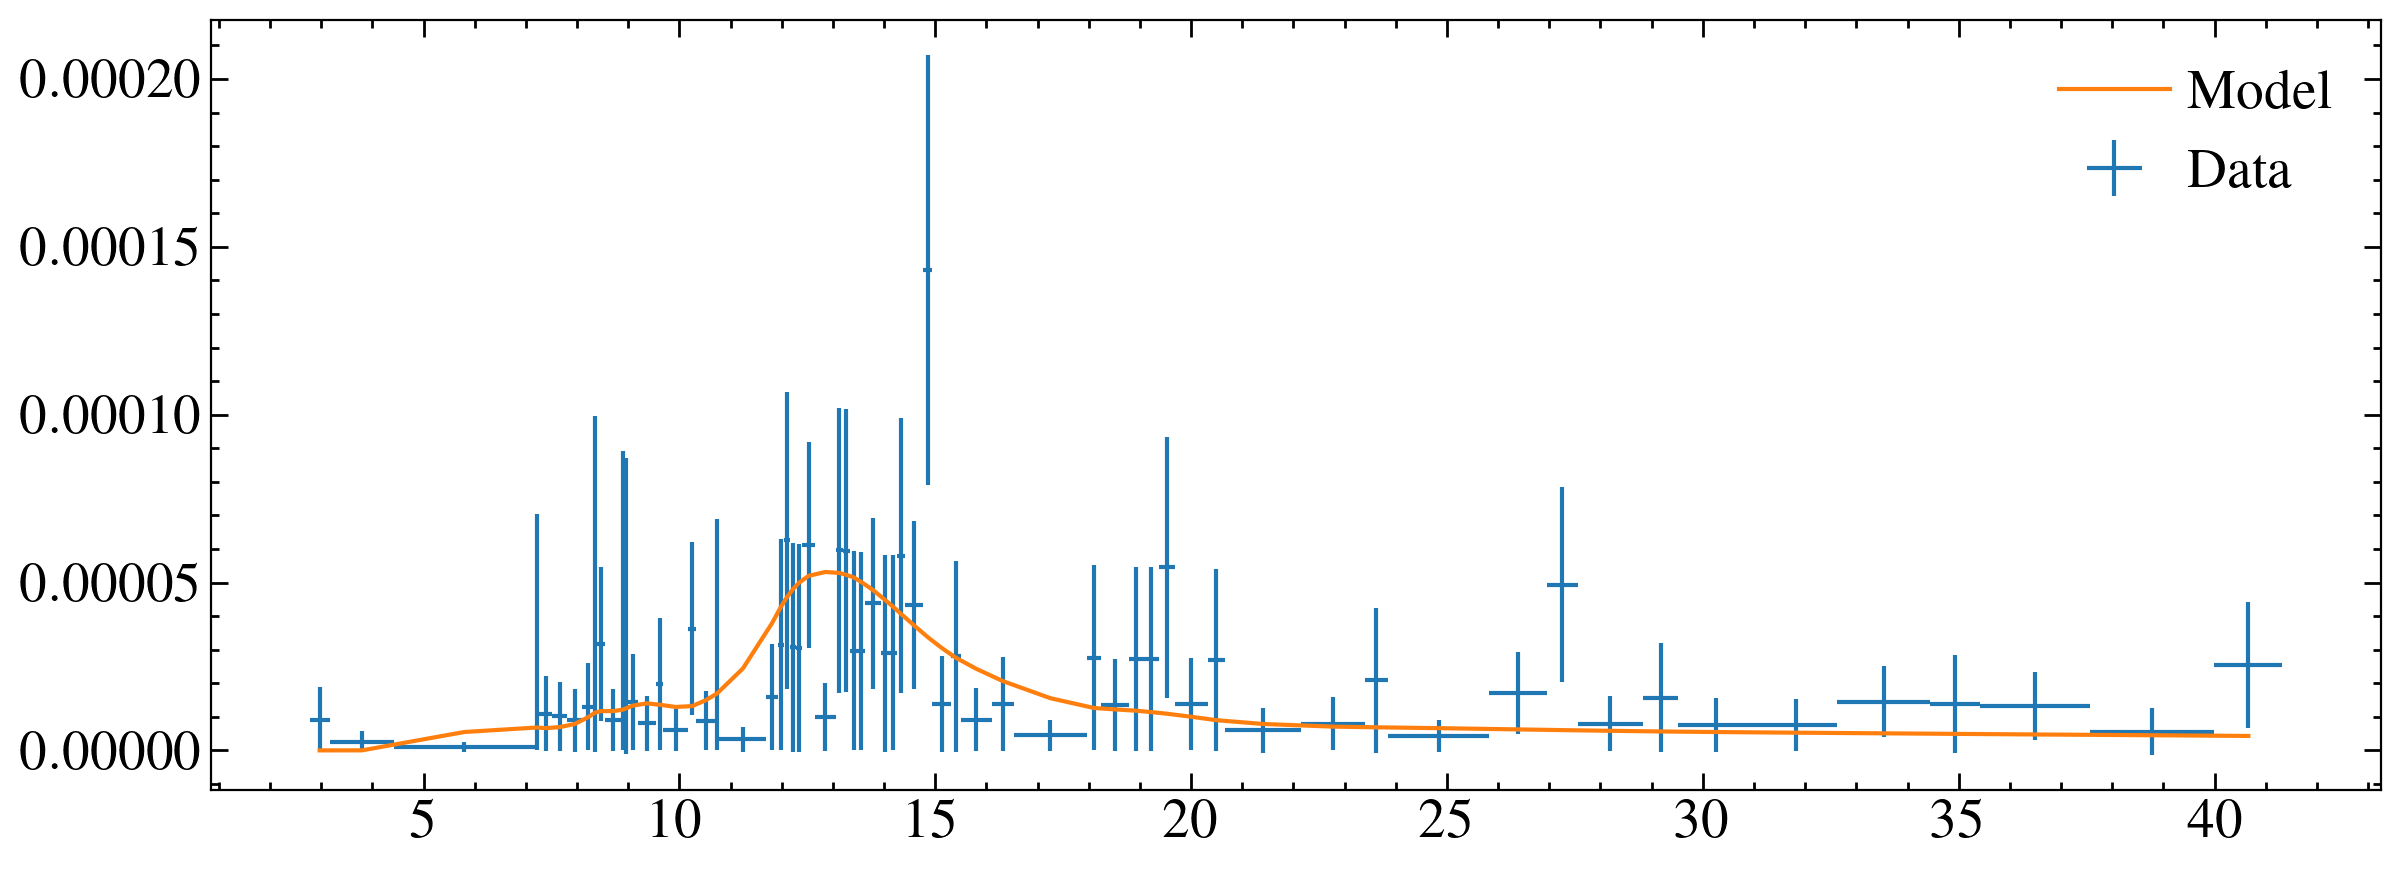

wolf1130
***Warning: Detected response matrix energy bin value = 0 (or neg).
     XSPEC will instead use small finite value (response file will not be altered).

1 spectrum  in use
 
Spectral Data File: Obs_00040011003pc.pi  Spectrum 1
Net count rate (cts/s) for Spectrum:1  3.222e-02 +/- 5.057e-03 (93.0 % total)
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-634
  Telescope: SWIFT Instrument: XRT  Channel Type: PI
  Exposure Time: 1356 sec
 Using fit statistic: cstat
 Using Background File                Obs_00040011003pcback.pi
  Background Exposure Time: 1356 sec
 Using Response (RMF) File            Obs_00040011003pc.rmf for Source 1
 Using Auxiliary Response (ARF) File  Obs_00040011003pc.arf


Fit statistic  : C-Statistic                   61.12     using 634 bins.

Test statistic : Chi-Squared                  366.37     using 634 bins.

***Warning: Chi-square may not be valid due to bins with zero variance
            in spectrum number(s): 1 

 Null hypothesis

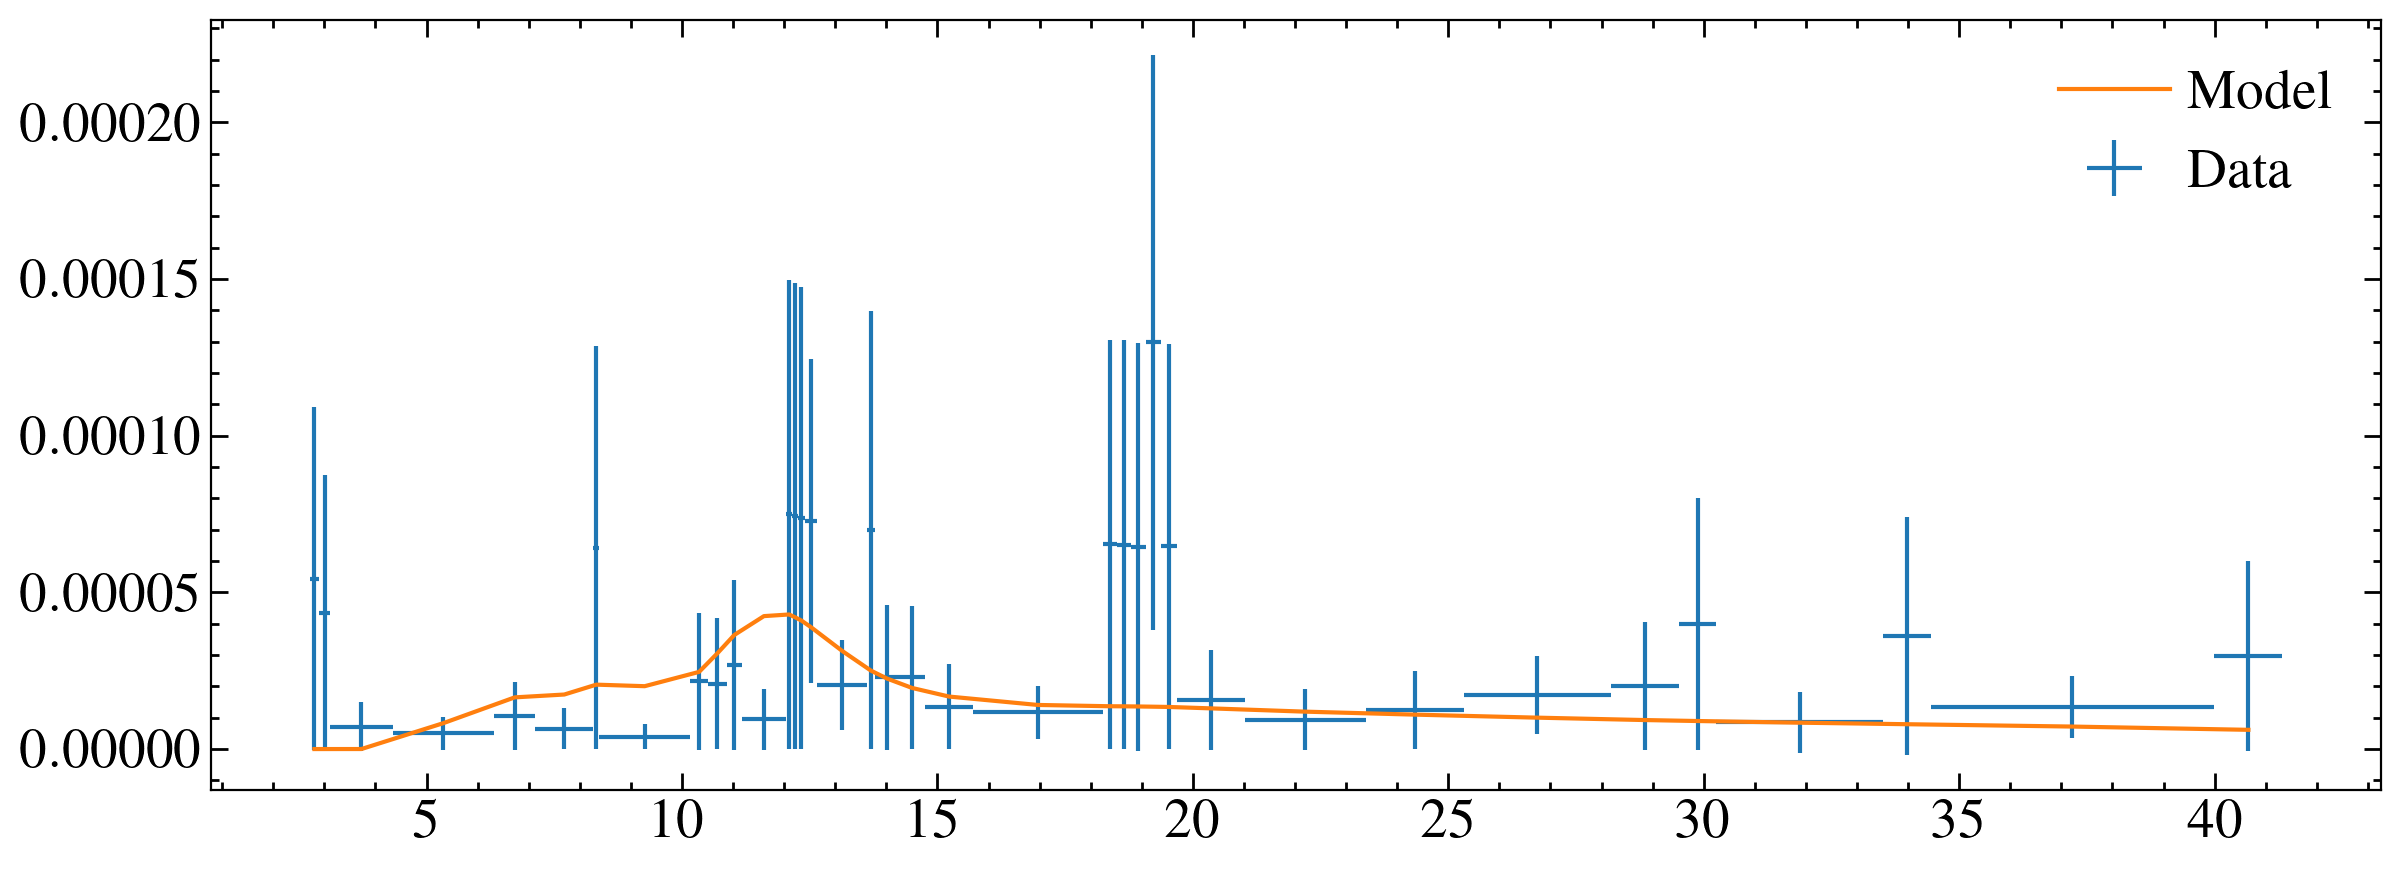

In [13]:
# napec = [1, 1, 1]
napec = [2,1,1]
fluxes = []
fluxes_eu = []
fluxes_el = []


for i, star in enumerate(stars):
    print(star)

    fig, ax = plt.subplots()
    # ax.set_xscale('log')
    
    # s = Spectrum('{}_src_spectrum_bin{}.ds'.format(star, specbins[i]), backFile='{}_bkg_spectrum_grp.ds'.format(star), respFile='{}_response_grp.rmf'.format(star))#, arfFile='{}_EMOS1.arf'.format(star))
    # starpath = '{}{}/swift/xrt/spectra/obs{}/'.format(path, star, obs[i])
    # src = glob.glob('{}*pc.pi'.format(starpath))[0]
    # bk = glob.glob('{}*pcback.pi'.format(starpath))[0]
    # rmf = glob.glob('{}*pc.rmf'.format(starpath))[0]
    # arf = glob.glob('{}*pc.arf'.format(starpath))[0]
    # print(src, bk, rmf, arf)
    src = '{}pc.pi'.format(obsname[i])
    # s = Spectrum(src, backFile=bk, respFile=rmf, arfFile=arf)
    s = Spectrum(src)
     
    
    Plot('data')
    Plot.xAxis='angstrom'
    # s.ignore('**-5.0 50.0-**')
    # s.ignore('bad')
    AllData.ignore("bad")

     
    Plot.perHz=False
    Plot.area=True
    Plot('data')
    mwave = Plot.x()
    
    # Plot.setRebin(3,5, 1)

    wave = Plot.x()
    rates = Plot.y()
    bins = Plot.xErr()
    error = Plot.yErr()
    

        
    
    ax.errorbar(wave, rates, xerr=bins, yerr=error, ls='none', label='Data')
    AllModels.setEnergies("0.1 2.4")


    # plt.errorbar(wave, rates)
    if napec[i] == 1:
        mod = Model('apec*phabs', setPars={1:0.5, 2:0.4, 5:1e-4})
        mod.phabs.nH.frozen = True
        Fit.statMethod = 'cstat'
        Fit.renorm()
        Fit.perform()
        Plot('data')
        folded = Plot.model()
        ax.plot(mwave, folded, label = 'Model')

    
    else:
    
        mod2 = Model('phabs*(apec+apec)', setPars={1:1e-4, 2:1,3:0.4,6:0.5, 7:0.4})
        mod2.phabs.nH.frozen = True
        Fit.renorm()
        Fit.perform()
        Plot('data')
        folded = Plot.model()
        ax.plot(mwave, folded, label = 'Model')

          
    flux = AllModels.calcFlux("0.1 2.4 err")
    print(flux)
    ax.legend()
    plt.show()
    # s.flux[0]*u.erg/u.cm**2/u.s, (s.flux[0]-s.flux[1])*u.erg/u.cm**2/u.s, (s.flux[2]-s.flux[0])*u.erg/u.cm**2/u.s  
    
    fluxes.append(s.flux[0])
    fluxes_eu.append(s.flux[2]-s.flux[0])
    fluxes_el.append(s.flux[0]-s.flux[1])
    
    
    DataManager.clear(s)
    
# print(napec)   


In [14]:
# Spectrum(src)

urgh it has to be done in this dir
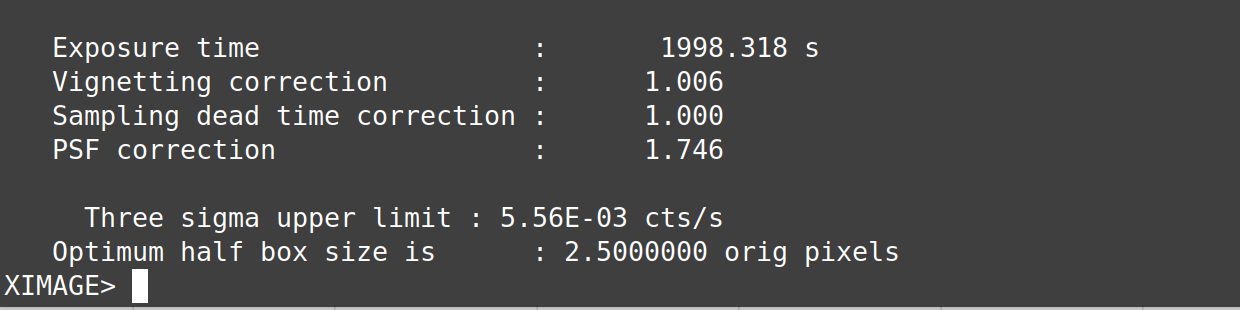

In [15]:
fluxes
print(fluxes)
print(fluxes_eu)
print(fluxes_el)

[1.77076145983696e-12, 7.887444481031084e-13, 9.429783906386728e-13]
[1.4670843578379753e-13, 7.346503447100228e-14, 1.7489012750330354e-13]
[1.769854466900453e-13, 7.813106104146773e-14, 1.1909662940915785e-13]


In [16]:
params = Table.read('../cool_pceb_params.csv')
# params

In [17]:
#g203-47
# upper_limit = 5.6e-3 cts/c
#webpimms with kt = 04_675
# 1.474E-13
#webpimms with kt = 1.0
# 1.366E-13
flim = 1.4e-13 

# f = []
# fluxes_eu = []
# fluxes_el = []

fxs = np.array([3.0801022267047403e-12, 7.887444481031084e-13, -1.4e-13,  9.429783906386728e-13]) #adding in G230-47 by hand so its in the same order as the params file

fxeus = np.array([2.4734688669166114e-13, 7.100708975680908e-14, 0.0, 1.5718129877541513e-13])

fxels = [1.554637412456115e-13, 8.174624119165697e-14, 0.0, 1.6605915263693952e-13]


In [18]:
xpath = '/media/david/2tb_ext_hd/hddata/carmenes_binary/xraycat/'
xraycat = fits.open('{}J_ApJ_743_48_catalog.dat.fits'.format(xpath))
xraydata = xraycat[1].data

0.000826736485151957 0.60417356 1.80125 0.00954798472720991 9.176774985186724e+28 erg / s
0.0008120714772822516 0.30992678 2.01825 0.0029717283277567504 2.501180150029335e+28 erg / s
2.827612103327233e-05 14.7136 2.4364999999999997 0.05385412142994919 9.246291577880052e+26 erg / s
0.0007031012098163282 0.49670418 1.5742500000000001 0.01323877541576151 3.142862407878987e+28 erg / s


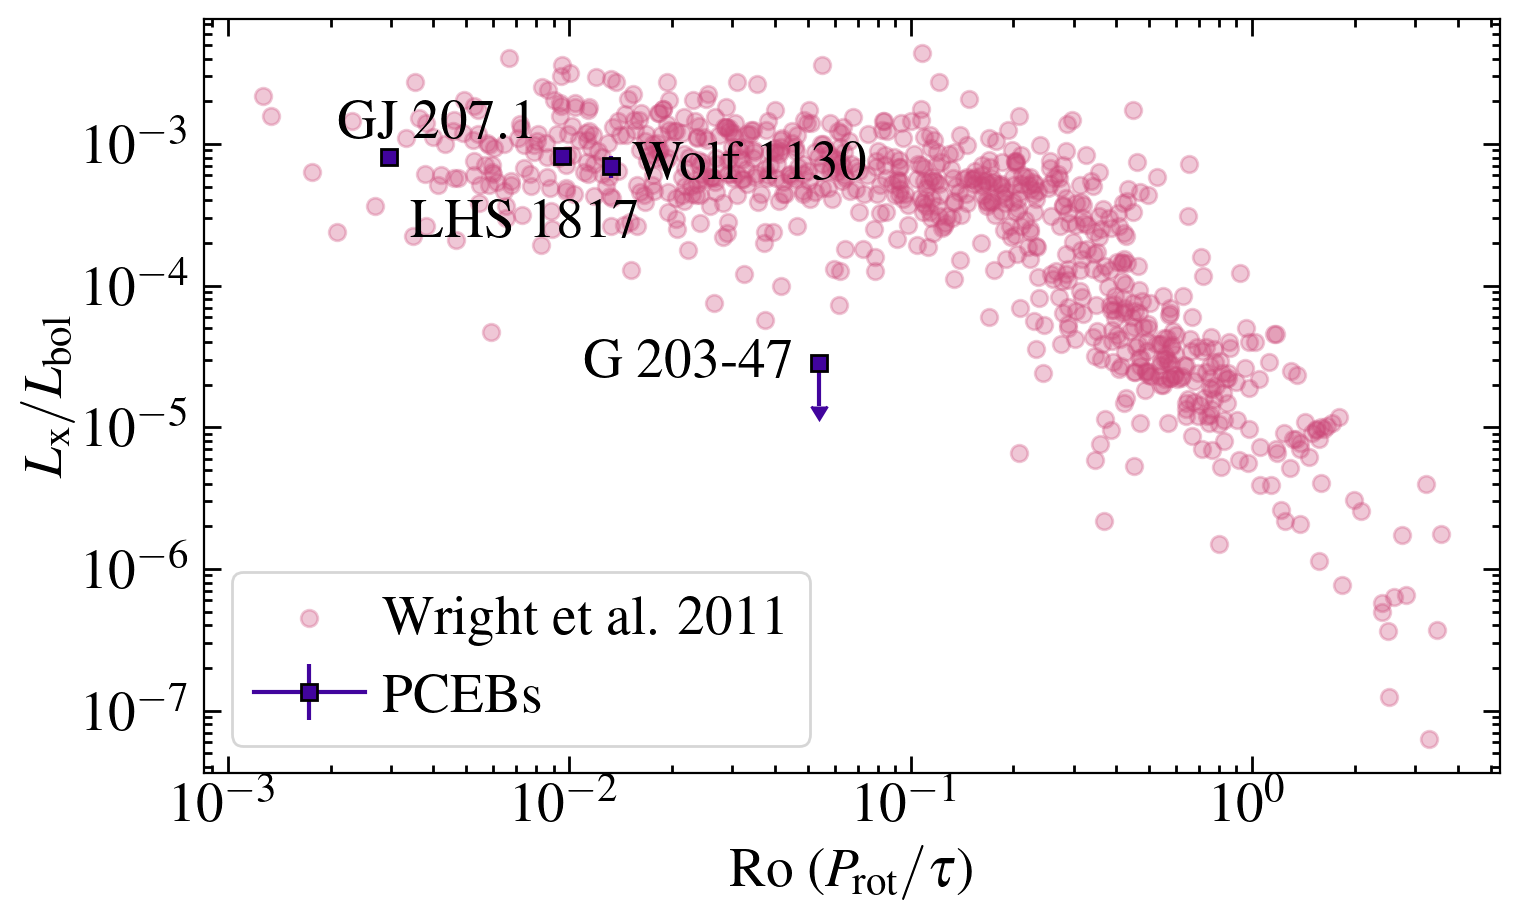

In [23]:
fig, ax = plt.subplots(figsize=(8,5))

hoffs = [0.85, 1.15,  0.85, 1.15]# where the labels go
voffs = [1.1, 0.5, 1.0, 1.0]
vas = ['bottom', 'top', 'center', 'center']

for i, row in enumerate(params):
    star = row['Name']
    prot = row['Porb']
    # if i == 2:
        # prot = 100
    ks = row['Ksmag']
    logtau = 0.64 + 0.25*(row['Vmag'] -row['Ksmag'])
    Ro = prot/ 10**logtau
    
    Lx = abs(fxs[i])*(u.erg/u.s/u.cm**2) * 4*np.pi*((row['Distance']*u.pc).to(u.cm))**2
    Lxbol = Lx/(row['L_dm']*u.erg/u.s)
    if fxs[i] > 0:
        err = np.array([[fxels[i]], [fxeus[i]]])*(Lxbol/fxs[i])
        # print(err.value)
        ax.errorbar(Ro, Lxbol, yerr=err, marker = 's', label ='PCEBs', zorder=10, markeredgecolor='k', color=plt.cm.plasma(0.1))
    else:
        err = 0.5*Lxbol 
        ax.errorbar(Ro, Lxbol, yerr=err, marker = 's', zorder=10, markeredgecolor='k', color=plt.cm.plasma(0.1), uplims=True)
    ha = 'right'
    if hoffs[i] > 1:
        ha = 'left'
    print(Lxbol, prot, logtau, Ro, Lx)
    
    ax.annotate(star, (Ro*hoffs[i], Lxbol.value*voffs[i]), ha=ha, va=vas[i])  
        
    




prots = xraydata['Prot']
vks = xraydata['V-K']
ros = prots / 10**(0.64 + 0.25*vks)

    
ax.scatter(ros, 10**xraydata['Lx/bol'], marker='o', alpha=0.3, label='Wright et al. 2011', color=plt.cm.plasma(0.5))
ax.set_xscale('log')
ax.set_yscale('log')
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), frameon=True)


ax.set_xlabel(r'Ro ($P_{\mathrm{rot}}/\tau$)')
# ax.set_xlabel(r'Ro ($P_{\mathrm{rot}}/\tau$, assuming $P_{\mathrm{rot}} = P_{\mathrm{orb}}$)')
ax.set_ylabel(r'$L_{\mathrm{x}}/L_{\mathrm{bol}}$')
fig.tight_layout()

fig.savefig('../plots/lx_v_rossby.pdf')
# fig.savefig('../plots/lx_v_rossby_assume.pdf')

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

hoffs = [0.85, 1.15,  0.85, 1.15]# where the labels go

for i, row in enumerate(params):
    star = row['Name']
    prot = row['Porb']
    logtau = 0.64 + 0.25*(row['Vmag'] -row['Ksmag'])
    Ro = prot/ 10**logtau
    Lx = abs(fxs[i])*(u.erg/u.s/u.cm**2) * 4*np.pi*((row['Distance']*u.pc).to(u.cm))**2
    Lxbol = Lx/row['L_dm']
    if fxs[i] > 0:
        err = np.array([[fxels[i]], [fxeus[i]]])*(Lxbol/fxs[i])
        # print(err.value)
        ax.errorbar(prot, Lxbol, yerr=err, marker = 's', label ='PCEBs', zorder=10, markeredgecolor='k', color=plt.cm.plasma(0.1))
    else:
        err = 0.5*Lxbol 
        ax.errorbar(prot, Lxbol, yerr=err, marker = 's', zorder=10, markeredgecolor='k', color=plt.cm.plasma(0.1), uplims=True)
    ha = 'right'
    if hoffs[i] > 1:
        ha = 'left'
    # ax.annotate(star, (Ro*hoffs[i], Lxbol.value*0.9), ha=ha, va='center')  
        
    




prots = xraydata['Prot']
vks = xraydata['V-K']
ros = prots / 10**(0.64 + 0.25*vks)

    
ax.scatter(prots, 10**xraydata['Lx/bol'], marker='o', alpha=0.3, label='Wright et al. 2011', color=plt.cm.plasma(0.5))
ax.set_xscale('log')
ax.set_yscale('log')
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), frameon=True)


ax.set_xlabel(r'$P_{\mathrm{rot}}$ (d)')
ax.set_ylabel(r'$L_{\mathrm{x}}/L_{\mathrm{bol}}$')
fig.tight_layout()

In [82]:
#for G203-47, implied 
Ro = 0.63
tau = 10**2.4364999999999997
prot_est = Ro*tau
prot_est

172.1236509643445

In [24]:
35e3/3600

9.722222222222221

2.8029233293851816e-05
0.6302858935409285
2.6860215027285146 2.6689671234395203 1.0636636330481108
733.8536946323285
290.6058220924439
0.395999671621251


/tmp/ipykernel_20613/234534985.py:23: RuntimeWarning: invalid value encountered in scalar power
  c = li * (ri ** (-1*b))


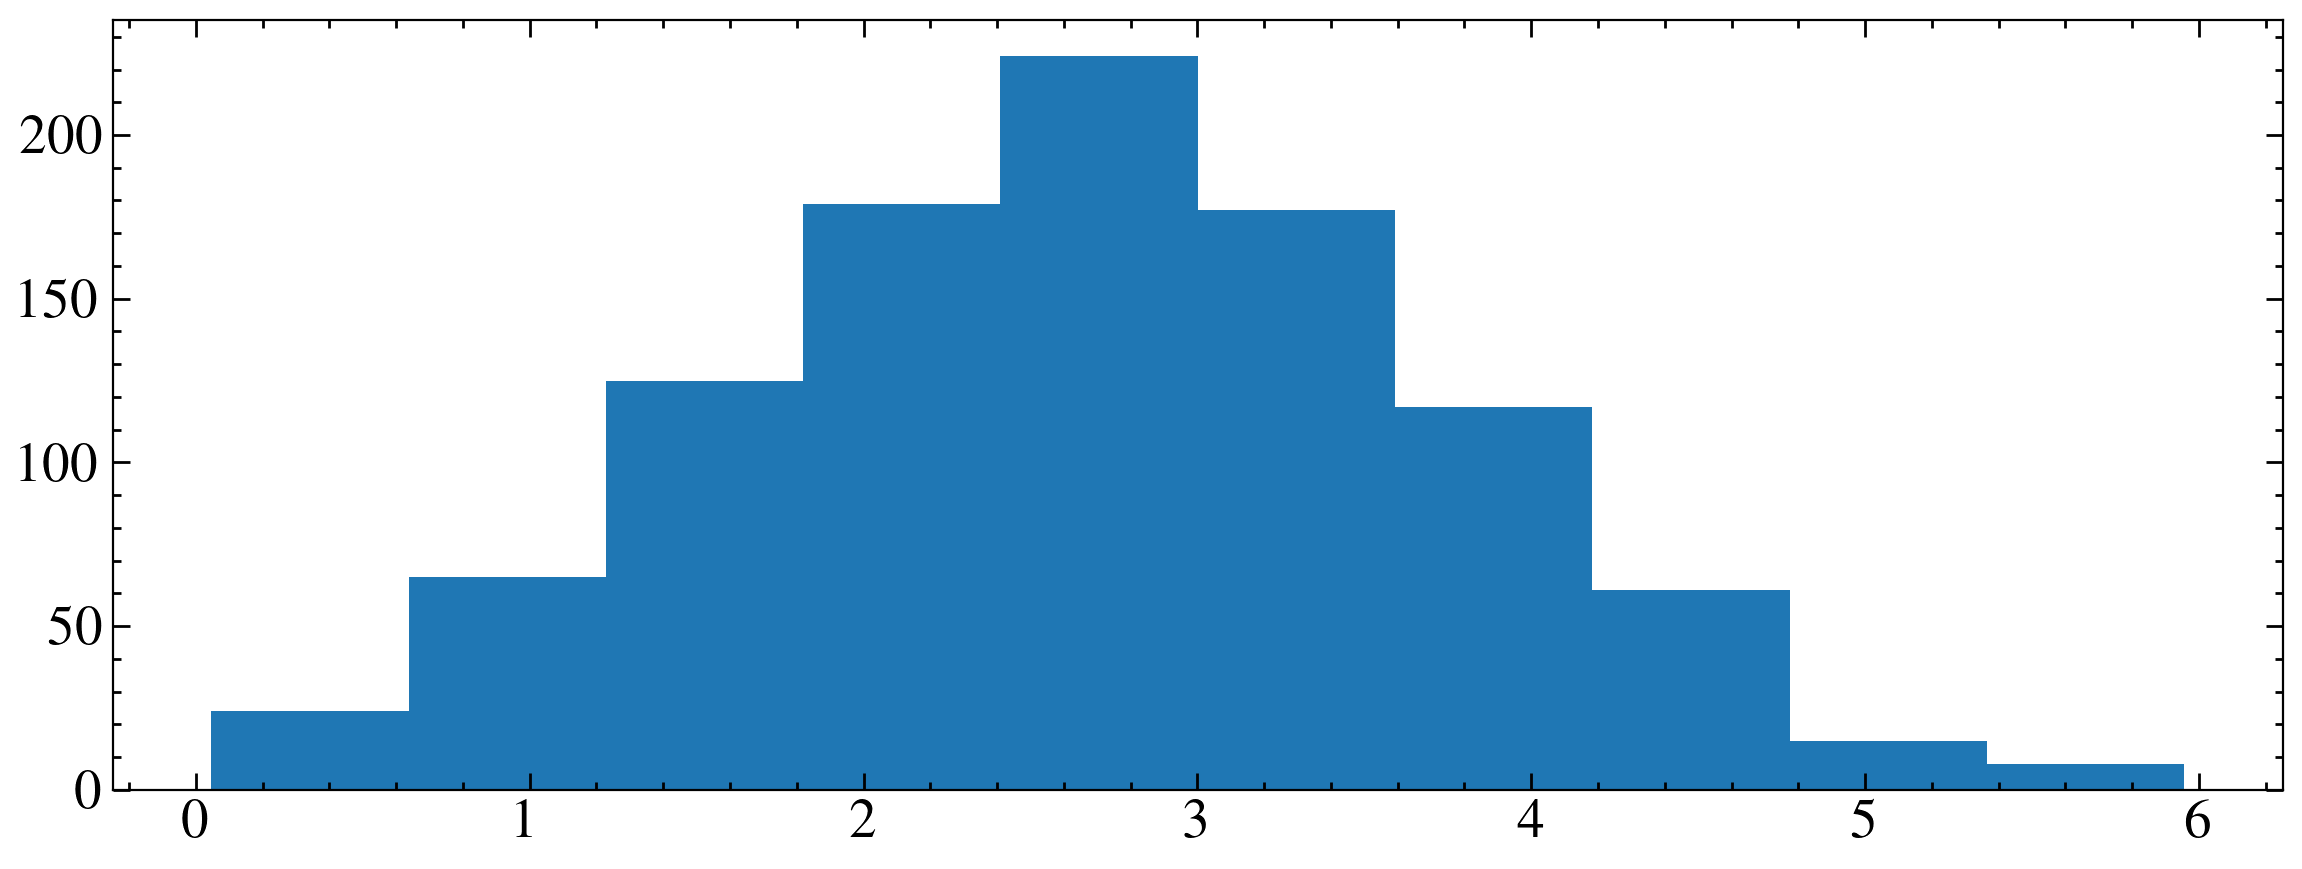

In [81]:
# 2.827612103327233e-05

c = (10**-3.05)* 0.14**2.3
print(c*0.63**-2.3)
print((2.8e-5/c)**(1/-2.3))



rsat, rsat_e = 0.14, 0.06
lsat, lsat_e = 10**-3.05, (10**(-3.05+0.05))-(10**-3.05)
# print(lsat, lsat_e)
b, be = -2.3, 0.5

n=1000
rs = np.random.normal(rsat, rsat_e, n)
ls = np.random.normal(lsat, lsat_e, n)
bs = np.random.normal(b, be, n)

rout = []
lxin = 1e-6
for i in range(n):
    ri, li, bi = rs[i], ls[i], bs[i]
    c = li * (ri ** (-1*b))
    rout.append((lxin/c)**(1/-2.3))

rout = np.array(rout)
rout = rout[np.isnan(rout)==False]
plt.hist(rout)
print(np.mean(rout), np.median(rout), np.std(rout))

print(np.mean(rout)*tau)
print(np.std(rout)*tau)
print((np.std(rout)*tau)/(np.mean(rout)*tau))



In [68]:
# np.isnan(rout)==False

In [ ]:
rag, deg = 